In [465]:
import numpy as np
import pandas as pd

In [466]:
df = pd.read_csv("Titanic.csv")

In [467]:
print(df.head())

   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  


In [468]:
print(df.shape)

(891, 15)


In [469]:
print(df.columns)

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='object')


In [470]:
print(df.isnull().sum())

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64


In [471]:
df['age'].fillna(df['age'].mean(),inplace = True)
df["embarked"].fillna("S", inplace=True)
df.dropna(inplace=True)

/tmp/ipykernel_4045/4238106152.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['age'].fillna(df['age'].mean(),inplace = True)
/tmp/ipykernel_4045/4238106152.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try

In [472]:
print(df.groupby('sex')["survived"].mean())

sex
female    0.936842
male      0.424528
Name: survived, dtype: float64


In [473]:
df['family_size'] = df["sibsp"] + df["parch"]
print(df.head())

    survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
1          1       1  female  38.0      1      0  71.2833        C  First   
3          1       1  female  35.0      1      0  53.1000        S  First   
6          0       1    male  54.0      0      0  51.8625        S  First   
10         1       3  female   4.0      1      1  16.7000        S  Third   
11         1       1  female  58.0      0      0  26.5500        S  First   

      who  adult_male deck  embark_town alive  alone  family_size  
1   woman       False    C    Cherbourg   yes  False            1  
3   woman       False    C  Southampton   yes  False            1  
6     man        True    E  Southampton    no   True            0  
10  child       False    G  Southampton   yes  False            2  
11  woman       False    C  Southampton   yes   True            0  


In [474]:
df.to_csv("CleanedDataset.csv")

In [475]:
import seaborn as sns
import matplotlib.pyplot as plt

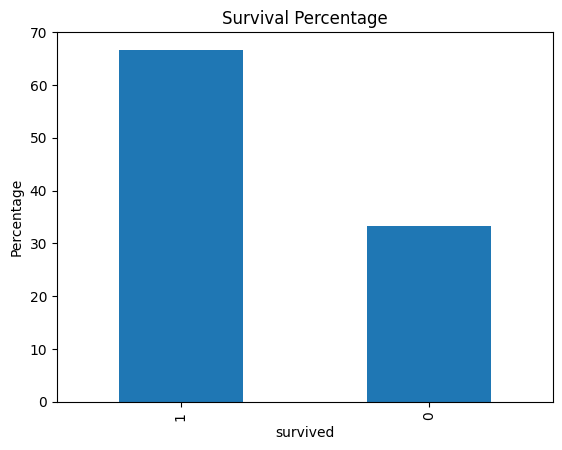

In [476]:
survival_rate = df["survived"].value_counts(normalize=True)*100
survival_rate.plot(kind="bar")
plt.title("Survival Percentage")
plt.ylabel("Percentage")
plt.show()

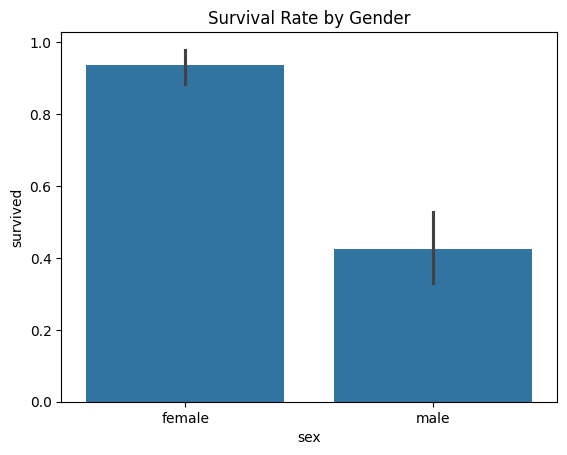

In [477]:
sns.barplot(x="sex", y="survived", data = df)
plt.title("Survival Rate by Gender")
plt.show()

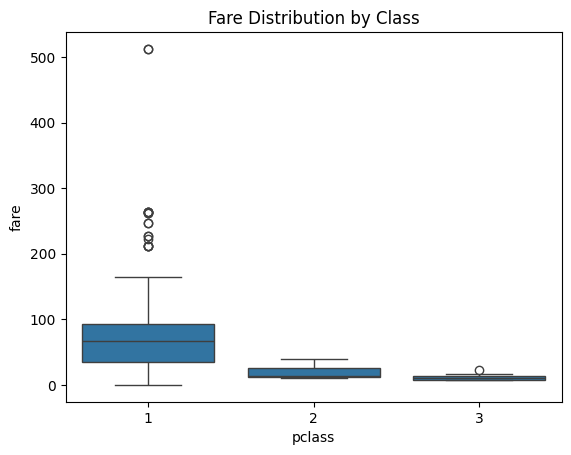

In [478]:
sns.boxplot(x="pclass", y="fare", data=df)
plt.title("Fare Distribution by Class")
plt.show()

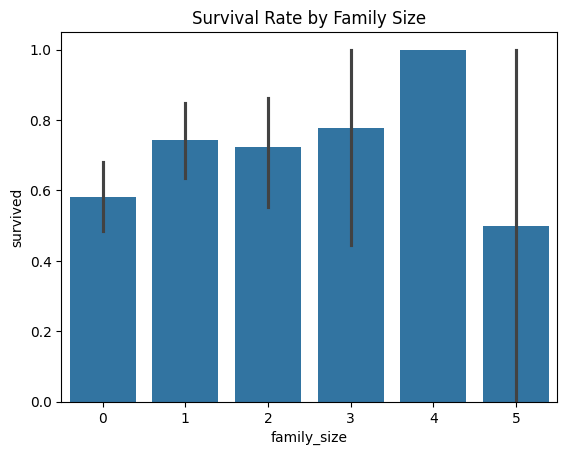

In [479]:
# df["Family_size"]=df["SibSp"] + df["Parch"]
sns.barplot(x="family_size", y="survived", data=df)
plt.title("Survival Rate by Family Size")
plt.show()

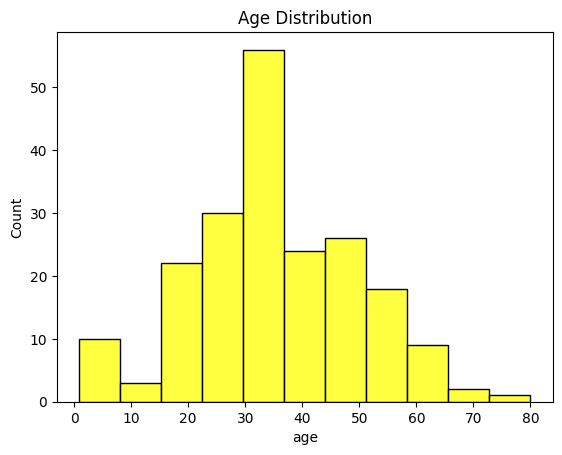

In [480]:
sns.histplot(df["age"],color="yellow")
plt.title("Age Distribution")
plt.show()

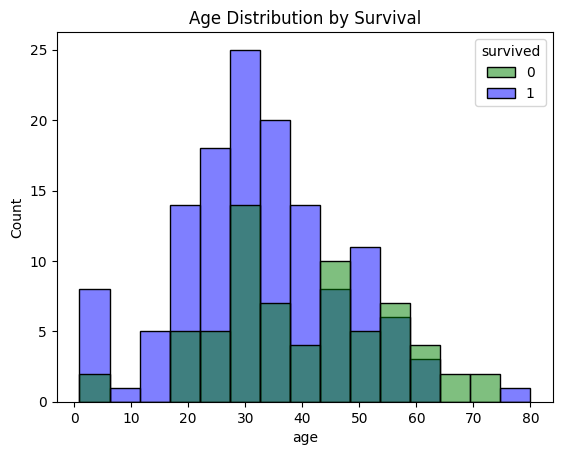

In [481]:
sns.histplot(x="age", hue="survived",data=df, palette=["green","blue"],bins=15)
plt.title("Age Distribution by Survival")
plt.show()

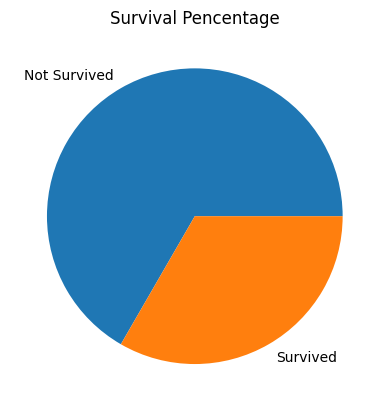

In [482]:
Survival = df["survived"].value_counts()
plt.pie(Survival, labels=["Not Survived","Survived"])
plt.title("Survival Pencentage")
plt.show()

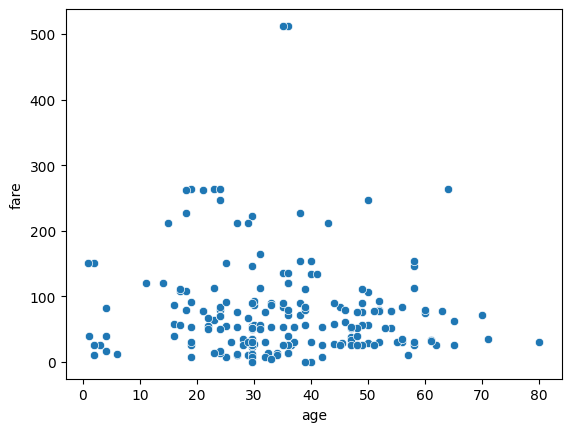

In [483]:
sns.scatterplot(x="age", y="fare", data=df)
plt.show()

In [484]:
from sklearn.model_selection import train_test_split
from sklearn .linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

In [485]:
df["embarked"].fillna("S", inplace=True)

/tmp/ipykernel_4045/1445940086.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["embarked"].fillna("S", inplace=True)


In [486]:
df.drop(["class","who","adult_male","deck","embark_town","alive"], axis = 1, inplace=True)

In [487]:
df["sex"] = df["sex"].map({"Male":0, "Female":1})
df["embarked"] = df["embarked"].map({"S":0, "C":1, "Q":2})
df["alone"] = df["alone"].map({True:1,False:0})
df.fillna(0, inplace=True)

In [488]:
x = df.drop("survived", axis = 1)
y = df["survived"]

In [489]:
x_train,x_test,y_train,y_test = train_test_split(
    x,y,test_size=0.2,random_state=67
)

In [490]:
model = LogisticRegression(max_iter = 1000)
model.fit(x_train, y_train)

LogisticRegression(max_iter=1000)

In [491]:
y_pred = model.predict(x_test)

Accuracy: 0.7805


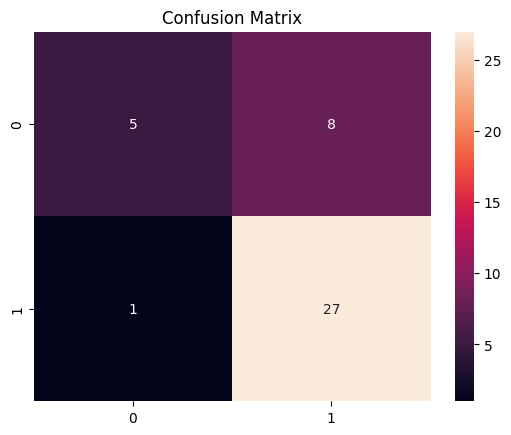

In [492]:
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
sns.heatmap(conf_matrix, annot = True, fmt="d")
plt.title("Confusion Matrix")
plt.show()